In [7]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


In [8]:
# create data 
N = 30
x = torch.randn(N,1)
y=x*x


In [9]:
# parameters
learningRate = 0.05
layers = 2
numepoch = 500 # number of epoch means number of times we will go through the whole dataset

In [10]:
# build model
ANNModel = nn.Sequential(
    nn.Linear(1,layers),
    nn.ReLU(),
    nn.Linear(layers,1)
)

In [11]:
# training
lossfun = nn.MSELoss() # loss function as mean square error
optimizer = torch.optim.SGD(ANNModel.parameters(),lr=learningRate) # optimizer as stochastic gradient descent
losses = torch.zeros(numepoch)
for epochi in range(numepoch):
    yhat = ANNModel(x) # predicted output                    "forward pass"
    loss = lossfun(yhat,y) # calculate loss                  "Compute loss"
    losses[epochi] = loss.item() # save loss for plotting    "Compute loss"
    optimizer.zero_grad() # clear gradients                  "back prop"
    loss.backward() # backpropagation                        "back prop"
    optimizer.step() # update parameters                     "back prop"


C:\Users\arumu\AppData\Local\Temp\ipykernel_25432\2966497075.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


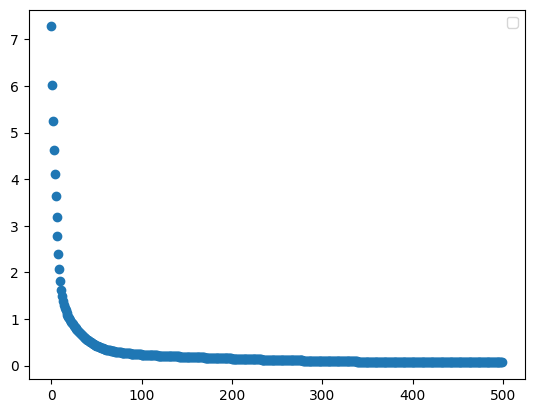

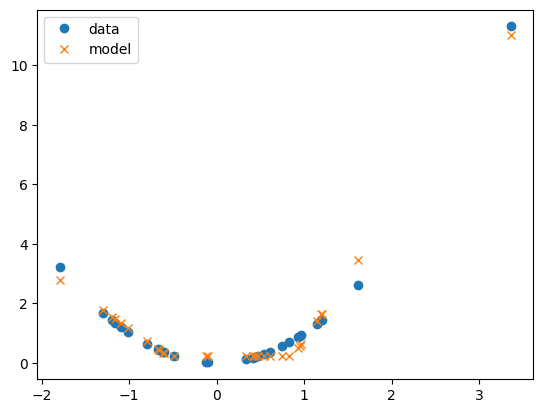

In [12]:
# plot loss and data
plt.plot(losses.detach(),'o')
plt.legend()
plt.show()

plt.plot(x.detach(),y.detach(),'o',label='data')
plt.plot(x.detach(),ANNModel(x).detach(),'x',label='model')
plt.legend()
plt.show()